
# Ablation Test: Time Domain + Frequency Domain vs Time Domain Only

This notebook performs an ablation test by comparing `DualBranchAutoencoder` and `TimeOnlyAutoencoder`. 
The hyperparameters have been carefully selected so that both models have an equivalent number of parameters (~2.02M).


In [1]:

import sys
import os
from pathlib import Path
import json
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import random

# Adjust the path to include the ML_denoising root directory
ROOT_DIR = Path("/pbs/home/o/omacias/Sam_project/raytune_lib_final").resolve()
sys.path.insert(0, str(ROOT_DIR))

from training.models.cnn import DualBranchAutoencoder, TimeOnlyAutoencoder
from training.raytune_training_function import CustomDataset, split_indices, multi_domain_l1_loss, psnr, get_peak_amplitude
from utils.data_preprocessing import produce_noise_and_noiseless_data

# Ensure we're running on GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


/sps/grand/macias/conda_envs/ili-torch/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-06-09 23:02:08,467	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-06-09 23:02:09,590	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Using device: cuda


#### Data Processing

In [2]:

# Data Loading Setup
# NOTE: Make sure `sim_data_dir` points to your dataset.
sim_data_dir = "/sps/grand/blevy/sims/sims_for_denoising_sept2025"

print("Loading data... (This might take a while)")
try:
    noise_signals, clean_signals = produce_noise_and_noiseless_data(sim_data_dir)
    clean_signals = np.array(clean_signals)  # Load entirely into RAM to avoid I/O bottleneck
    print("Data loaded successfully.")
    
    # Split the dataset
    n_samples = noise_signals.shape[1]
    train_indices, valid_indices, test_indices = split_indices(n_samples)
    
    train_dataset = CustomDataset(clean_signals, [noise_signals], indices=train_indices, 
                                    swap_prob=0.5, target_start=120, target_end=480, voltage_to_adc=True)


    valid_dataset = CustomDataset(clean_signals, [noise_signals], indices=valid_indices,
                                    swap_prob=0.5, target_start=120, target_end=480, voltage_to_adc=True)


    test_dataset = CustomDataset(clean_signals, [noise_signals], indices=test_indices,
                            swap_prob=0.5, target_start=120, target_end=480, voltage_to_adc=True)
    
    batch_size = 1024
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
    valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, pin_memory=True)
    
    data_available = True
except Exception as e:
    print(f"Failed to load data from {sim_data_dir}.")
    print(e)
    data_available = False


Loading data... (This might take a while)
Loaded noise file 0: shape (3, 12500, 1024)
Noise signals shape: (3, 300000, 1024)
Clean signals shape: (3, 410673, 1024)
Data loaded successfully.


#### Train Time only model and Dual Model Autoencoder with fixed parameters

In [3]:
import os
import csv

def train_model(model, name, epochs=50, lr=1e-4, force_train=False, seed=42):
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed(seed)
            torch.cuda.manual_seed_all(seed)
        # Force cuDNN to use deterministic algorithms
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    if not data_available:
        print("Data not available. Skipping training.")
        return [], []
        
    ckpt_path = f"{name}_best.pt"
    csv_path = f"{name}_loss_history.csv"
    
    # Check if checkpoint exists
    if os.path.exists(ckpt_path):
        print(f"[{name}] Checkpoint found at {ckpt_path}. Loading weights...")
        model.load_state_dict(torch.load(ckpt_path, map_location=device))
        
        # If we don't want to force training after loading, just return
        if not force_train:
            print(f"[{name}] Skipping training. Set force_train=True to resume/force training.")
            
            if os.path.exists(csv_path):
                print(f"[{name}] Loading loss history from {csv_path}...")
                t_loss, v_loss = [], []
                with open(csv_path, mode='r') as f:
                    reader = csv.DictReader(f)
                    for row in reader:
                        t_loss.append(float(row['train_loss']))
                        v_loss.append(float(row['val_loss']))
                return t_loss, v_loss
                
            return [], []
        else:
            print(f"[{name}] Resuming training from checkpoint...")
            
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    
    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        
        for batch_idx, (noised, clean) in enumerate(train_loader):
            noised, clean = noised.to(device), clean.to(device)
            optimizer.zero_grad()
            
            output = model(noised)
            loss = multi_domain_l1_loss(clean, output, mag_weight=0.1, phase_weight=0.1)
            
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()
            
        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        # Validation
        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for noised, clean in valid_loader:
                noised, clean = noised.to(device), clean.to(device)
                output = model(noised)
                loss = multi_domain_l1_loss(clean, output, mag_weight=0.1, phase_weight=0.1)
                total_val_loss += loss.item()
                
        avg_val_loss = total_val_loss / len(valid_loader)
        val_losses.append(avg_val_loss)
        scheduler.step(avg_val_loss)
        
        print(f"[{name}] Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        
        # Save best checkpoint
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), ckpt_path)
    
        with open(csv_path, mode='w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(['epoch', 'train_loss', 'val_loss'])
            for e, (t_l, v_l) in enumerate(zip(train_losses, val_losses), 1):
                writer.writerow([e, t_l, v_l])
            
    return train_losses, val_losses


In [4]:
import json
# Helper function to calculate the number of model parameters
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)
# ==========================================
# 1. Retain Frequency Branch (Control Group / Full Model)
# ==========================================
config_with_freq = {
    'use_freq_branch': True,    # Keep frequency branch enabled
    'time_branch': {'conv_channels': 32, 'res_channels': (128, 256)},
    'freq_branch': {'conv_channels': 16, 'res_channels': (128, 256)},
    'decoder_channels': [128, 64, 32, 3]
}
# ==========================================
# 2. Disable Frequency Branch (Experimental Group / Ablation)
# ==========================================
config_no_freq = {
    'use_freq_branch': False,   # Disable frequency branch for a pure ablation test
    'time_branch': {'conv_channels': 32, 'res_channels': (128, 256)}, # Parameters must match exactly with the model above
    'freq_branch': {'conv_channels': 16, 'res_channels': (128, 256)}, 
    'decoder_channels': [128, 64, 32, 3]
}
# Instantiate both models (both use the DualBranchAutoencoder architecture)
model_dual = DualBranchAutoencoder(config_with_freq).to(device)
model_time = DualBranchAutoencoder(config_no_freq).to(device)
print(f"DualBranchAutoencoder params: {count_parameters(model_dual)}")
print(f"DualBranch_NoFreq params:     {count_parameters(model_time)}")
# Save the configurations to a JSON file for future reference
ablation_configs = {
    "DualBranch": config_with_freq,
    "TimeOnly": config_no_freq
}
with open("ablation_configs.json", "w") as f:
    json.dump(ablation_configs, f, indent=4)

DualBranchAutoencoder params: 2028566
DualBranch_NoFreq params:     534294


In [5]:

epochs = 100
print("Starting training for DualBranchAutoencoder...")
train_loss_freq, val_loss_freq = train_model(model_dual, "DualBranch_WithFreq", epochs=epochs, force_train=False)


print("\nStarting training for TimeOnlyAutoencoder...")
train_loss_nofreq, val_loss_nofreq = train_model(model_time, "DualBranch_NoFreq", epochs=epochs, force_train=False)


Starting training for DualBranchAutoencoder...
[DualBranch_WithFreq] Checkpoint found at DualBranch_WithFreq_best.pt. Loading weights...


/tmp/ipykernel_3230321/1833806171.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt_path, map_location=device))


[DualBranch_WithFreq] Skipping training. Set force_train=True to resume/force training.
[DualBranch_WithFreq] Loading loss history from DualBranch_WithFreq_loss_history.csv...

Starting training for TimeOnlyAutoencoder...
[DualBranch_NoFreq] Checkpoint found at DualBranch_NoFreq_best.pt. Loading weights...
[DualBranch_NoFreq] Skipping training. Set force_train=True to resume/force training.
[DualBranch_NoFreq] Loading loss history from DualBranch_NoFreq_loss_history.csv...


##### Loss vs Epochs 

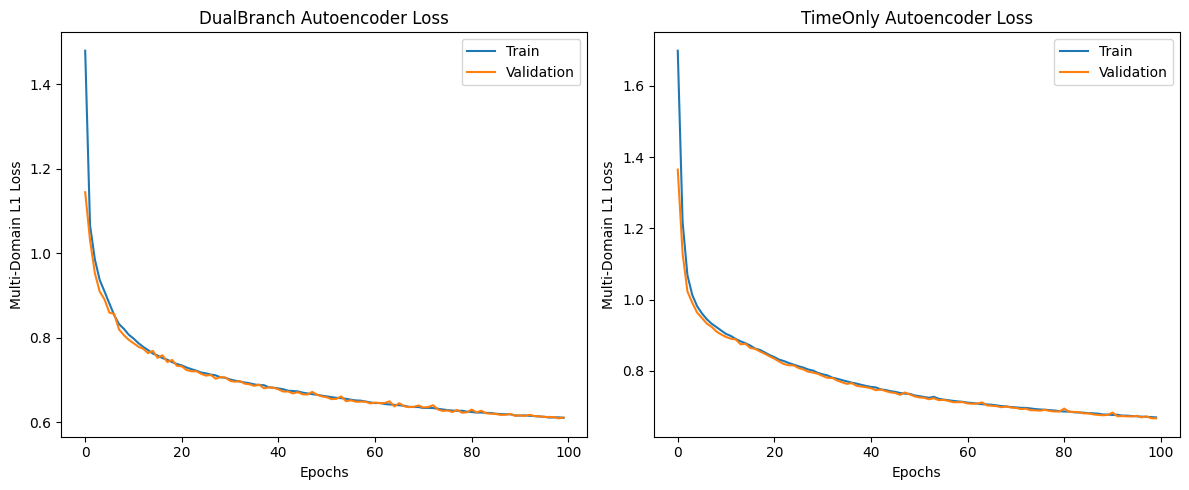

In [6]:

if data_available:
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(train_loss_freq, label='Train')
    plt.plot(val_loss_freq, label='Validation')
    plt.title('DualBranch Autoencoder Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Multi-Domain L1 Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(train_loss_nofreq, label='Train')
    plt.plot(val_loss_nofreq, label='Validation')
    plt.title('TimeOnly Autoencoder Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Multi-Domain L1 Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig('ablation_learning_curves.pdf')
    plt.show()


#### Evaluation plot

In [7]:

def evaluate_model(model, name):
    if not data_available:
        return {"psnr_avg": 0, "peak_ratio_avg": 0}
        
    model.eval()
    psnr_list = []
    peak_ratio_list = []
    
    print(f"Evaluating {name} on test set...")
    with torch.no_grad():
        for noised, clean in test_loader:
            noised, clean = noised.to(device), clean.to(device)
            output = model(noised)
            
            clean_np = clean.cpu().numpy().squeeze()
            out_np = output.cpu().numpy().squeeze()
            
            # Use max peak amplitude as scale for PSNR
            peak_amp = get_peak_amplitude(clean_np)
            current_psnr = psnr(out_np, clean_np, peak_amp)
            psnr_list.append(current_psnr)
            
            # Peak to peak ratio
            out_peak = get_peak_amplitude(out_np)
            ratio = abs(peak_amp - out_peak) / peak_amp
            peak_ratio_list.append(ratio)
            
    return {
        "psnr_avg": float(np.mean(psnr_list)),
        "psnr_std": float(np.std(psnr_list)),
        "peak_ratio_avg": float(np.mean(peak_ratio_list)),
        "peak_ratio_std": float(np.std(peak_ratio_list))
    }

#### best checking pt

In [8]:

if data_available:
    # Load best weights before evaluating
    if os.path.exists("DualBranch_best.pt"):
        model_dual.load_state_dict(torch.load("DualBranch_WithFreq_best.pt", map_location=device, weights_only=True))
    if os.path.exists("TimeOnly_best.pt"):
        model_time.load_state_dict(torch.load("DualBranch_NoFreq_best.pt", map_location=device, weights_only=True))
        
    dual_results = evaluate_model(model_dual, "DualBranch")
    time_results = evaluate_model(model_time, "TimeOnly")

    results = {
        "DualBranch": dual_results,
        "TimeOnly": time_results
    }

    # Save to JSON
    with open("ablation_metrics.json", "w") as f:
        json.dump(results, f, indent=4)
        
    # Save to CSV
    import pandas as pd
    df = pd.DataFrame(results).T
    df.to_csv("ablation_metrics.csv")
    
    print("\nFinal Test Metrics:")
    print(df)


Evaluating DualBranch on test set...
Evaluating TimeOnly on test set...

Final Test Metrics:
             psnr_avg  psnr_std  peak_ratio_avg  peak_ratio_std
DualBranch  26.726925  8.624847        0.334360        0.314738
TimeOnly    26.261223  7.823408        0.368114        0.321195


#### Ablation plot for peak time efficiency

Saved comparison plot to figures_csv/ablation_peak_efficiency_comparison.pdf


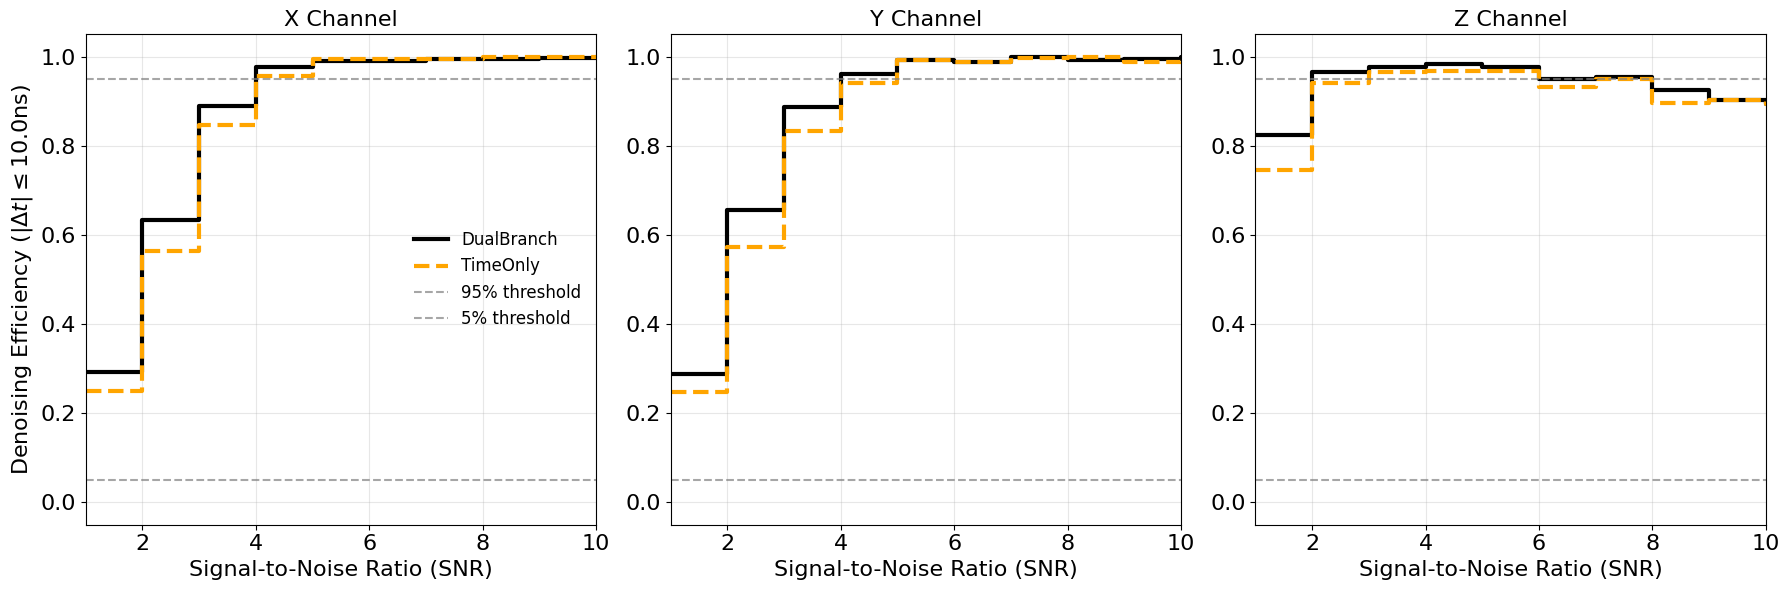

In [10]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert
from visualization.overleaf_plots import _estimate_noise_sigma
def ablation_peak_time_efficiency_comparison(
    dataloader,
    model_dual,
    model_time,
    device: str = "cpu",
    min_snr: float = 1.0,
    max_snr: float = 20.0,
    snr_bins_count: int = 19,
    dt_ns: float = 2.0,
    time_tolerance_ns: float = 10.0,
    save_path: str = "",
    trigger_k: float = 2.0,
    sigma_method: str = "mad",
    exclude_radius: int = 32,
    sigma_source: str = "envelope",
):
    """
    Compares the peak time efficiency of two models (DualBranch vs TimeOnly)
    using the rigorous Hilbert envelope method AND the trigger-like selection logic.
    """
    device = torch.device(device)
    model_dual.to(device)
    model_time.to(device)
    model_dual.eval()
    model_time.eval()
    
    results = {
        0: {"snr": [], "dual_err": [], "time_err": [], "noisy_amp": [], "sigma": []},
        1: {"snr": [], "dual_err": [], "time_err": [], "noisy_amp": [], "sigma": []},
        2: {"snr": [], "dual_err": [], "time_err": [], "noisy_amp": [], "sigma": []}
    }
    with torch.no_grad():
        for noisy_data, clean_data in dataloader:
            noisy_data = noisy_data.to(device)
            clean_data = clean_data.to(device)
            
            dual_output = model_dual(noisy_data)
            time_output = model_time(noisy_data)
            batch_size = noisy_data.size(0)
            for i in range(batch_size):
                for ch in range(3):
                    clean_np = clean_data[i, ch].cpu().numpy()
                    noisy_np = noisy_data[i, ch].cpu().numpy()
                    dual_np = dual_output[i, ch].cpu().numpy()
                    time_np = time_output[i, ch].cpu().numpy()
                    denom = np.std(noisy_np)
                    snr = (np.max(clean_np) / denom) if denom != 0 else float("inf")
                    if min_snr <= snr <= max_snr:
                        env_clean = np.abs(hilbert(clean_np))
                        env_noisy = np.abs(hilbert(noisy_np))
                        env_dual = np.abs(hilbert(dual_np))
                        env_time = np.abs(hilbert(time_np))
                        idx_peak_noisy = int(np.argmax(env_noisy))
                        
                        peak_clean = np.argmax(env_clean) * dt_ns
                        peak_dual = np.argmax(env_dual) * dt_ns
                        peak_time = np.argmax(env_time) * dt_ns
                        
                        peak_amp_noisy = float(np.max(env_noisy))
                        if sigma_source.lower() == "envelope":
                            sigma = _estimate_noise_sigma(
                                noisy_trace=env_noisy,
                                peak_index=idx_peak_noisy,
                                exclude_radius=exclude_radius,
                                method=sigma_method,
                            )
                        elif sigma_source.lower() == "waveform":
                            sigma = _estimate_noise_sigma(
                                noisy_trace=noisy_np,
                                peak_index=idx_peak_noisy,
                                exclude_radius=exclude_radius,
                                method=sigma_method,
                            )
                        else:
                            raise ValueError("sigma_source must be 'envelope' or 'waveform'.")
                        results[ch]["snr"].append(snr)
                        results[ch]["dual_err"].append(np.abs(peak_dual - peak_clean))
                        results[ch]["time_err"].append(np.abs(peak_time - peak_clean))
                        results[ch]["noisy_amp"].append(peak_amp_noisy)
                        results[ch]["sigma"].append(float(sigma))
    # ==========================
    # Plotting section 
    # ==========================
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fontsize = 16
    snr_bins = np.linspace(min_snr, max_snr, snr_bins_count + 1)
    channels = ["X Channel", "Y Channel", "Z Channel"]
    for ch in range(3):
        ax = axes[ch]
        
        snr_arr = np.array(results[ch]["snr"])
        dual_err_arr = np.array(results[ch]["dual_err"])
        time_err_arr = np.array(results[ch]["time_err"])
        noisy_amp_arr = np.array(results[ch]["noisy_amp"])
        sigma_arr = np.array(results[ch]["sigma"])
    
        pass_trigger = noisy_amp_arr >= (trigger_k * sigma_arr)
        
        dual_eff = []
        time_eff = []
        
        for i in range(len(snr_bins) - 1):
            in_bin = (snr_arr >= snr_bins[i]) & (snr_arr < snr_bins[i+1])

            mask = in_bin & pass_trigger
            
            if np.sum(mask) == 0:
                dual_eff.append(np.nan)
                time_eff.append(np.nan)
            else:
                dual_eff.append(np.mean(dual_err_arr[mask] <= time_tolerance_ns))
                time_eff.append(np.mean(time_err_arr[mask] <= time_tolerance_ns))
                
        ax.step(snr_bins[:-1], dual_eff, where='post', label='DualBranch', color='black', linewidth=3)
        ax.step(snr_bins[:-1], time_eff, where='post', label='TimeOnly', color='orange', linestyle='--', linewidth=3)
        
        ax.axhline(y=0.95, color="gray", linestyle="--", linewidth=1.5, alpha=0.7, label="95% threshold")
        ax.axhline(y=0.05, color="gray", linestyle="--", linewidth=1.5, alpha=0.7, label="5% threshold")
        
        ax.set_xlabel("Signal-to-Noise Ratio (SNR)", fontsize=fontsize)
        if ch == 0:
            ax.set_ylabel(f"Denoising Efficiency ($|\\Delta t| \\leq {time_tolerance_ns}$ns)", fontsize=fontsize)
        ax.set_title(f"{channels[ch]}", fontsize=fontsize)
        ax.tick_params(axis="both", which="major", labelsize=fontsize)
        

        ax.set_xlim(1, 10)
        ax.set_ylim(-0.05, 1.05)
        
        if ch == 0:
            ax.legend(fontsize=fontsize - 4, loc="center right", frameon=False)
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches='tight')
        print(f"Saved comparison plot to {save_path}")
    plt.show()

ablation_peak_time_efficiency_comparison(
    dataloader=test_loader,
    model_dual=model_dual,
    model_time=model_time,
    device=device,
    min_snr=1.0,
    max_snr=20.0,
    snr_bins_count=19,        
    dt_ns=2.0,               
    time_tolerance_ns=10.0,    
    save_path="figures_csv/ablation_peak_efficiency_comparison.pdf",
    trigger_k=2.0          
)

Running inference on test set...
Collected waveforms shape: (30000, 3, 512)
Generating fidelity plot...
Saved: ablation_nmse_snrgain_vs_snr.pdf


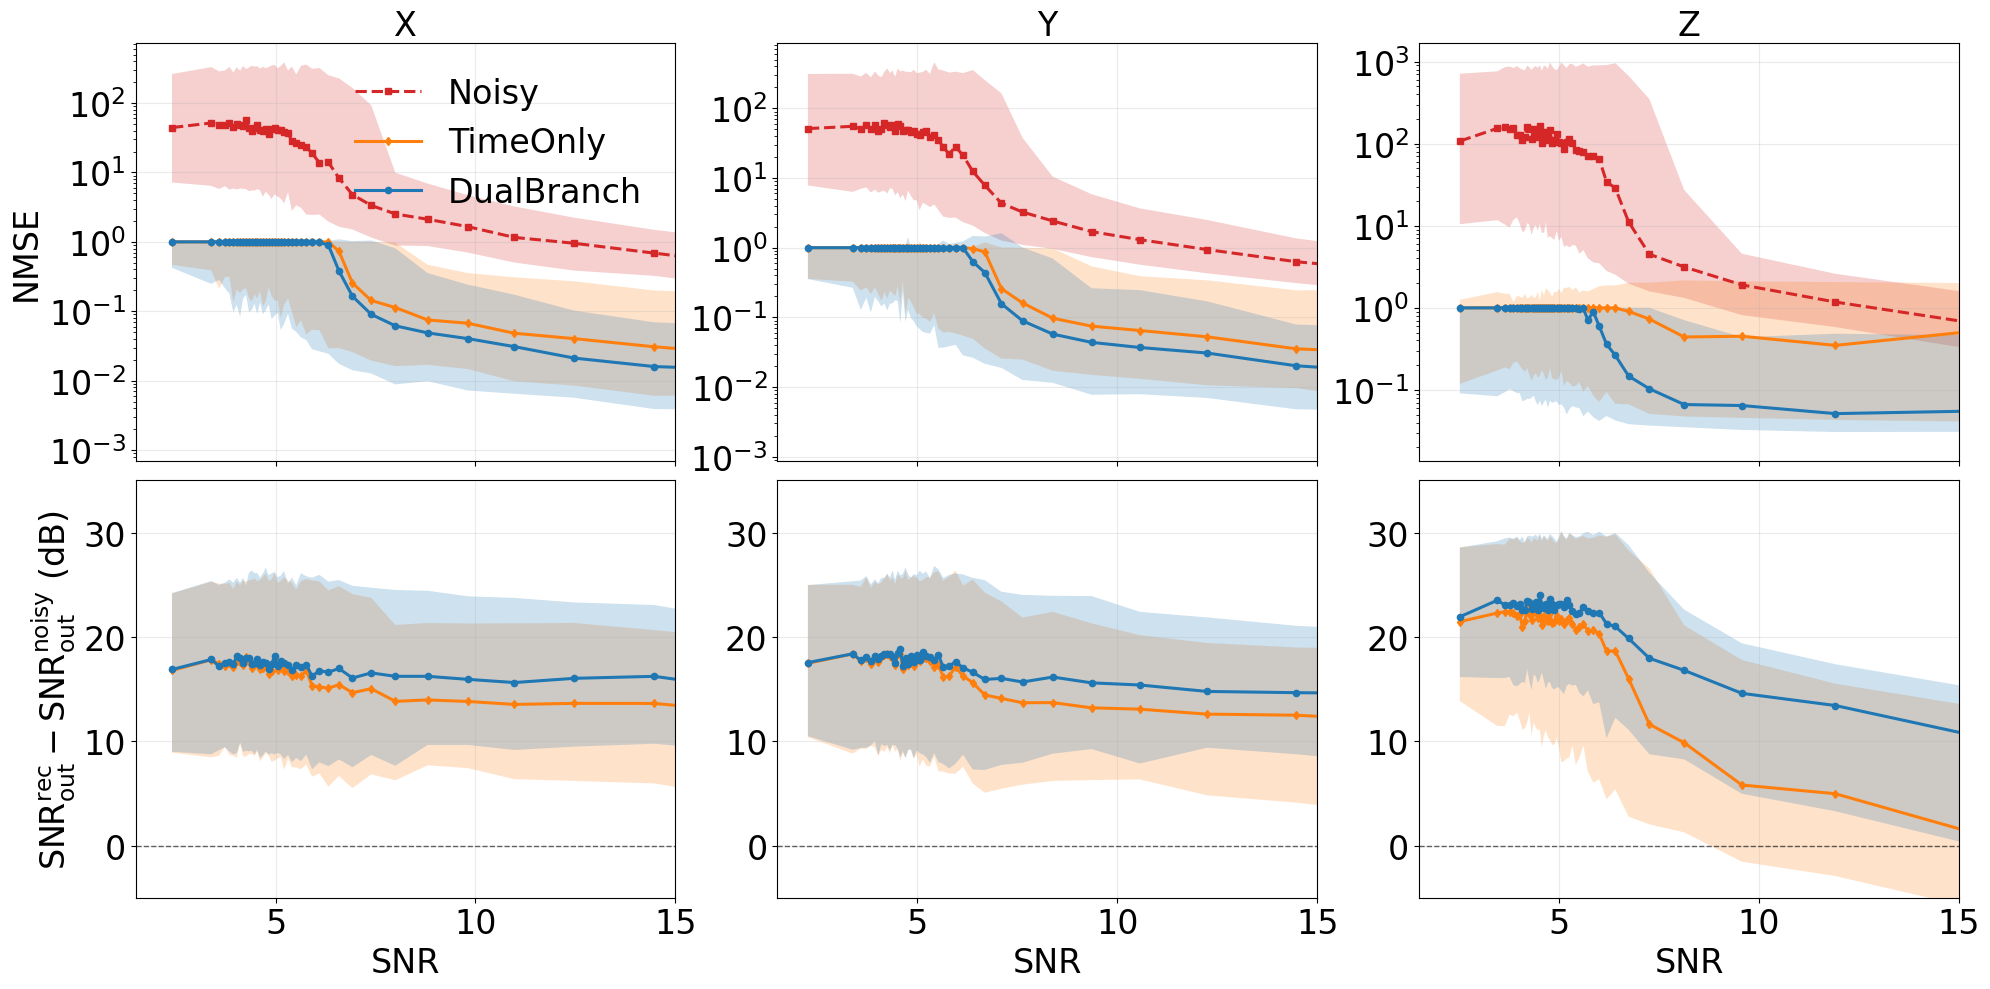

In [11]:
import torch
import numpy as np
from visualization.nmse_snr_gain_vs_snr.make_fig_nmse_snr_gain_vs_snr__option3_truth_cleanpower_gate import plot_nmse_and_snr_gain_vs_snr, FidelityPlotConfig

print("Running inference on test set...")
model_dual.eval()
model_time.eval()

noisy_list = []
clean_list = []
den_dual_list = []
den_time_list = []

# Collect all waveforms from the test loader
with torch.no_grad():
    for noised, clean in test_loader:
        noised_device = noised.to(device)
        
        # Inference for both models
        out_dual = model_dual(noised_device)
        out_time = model_time(noised_device)
        
        # Move back to CPU and numpy
        noisy_list.append(noised.numpy())
        clean_list.append(clean.numpy())
        den_dual_list.append(out_dual.cpu().numpy())
        den_time_list.append(out_time.cpu().numpy())

# Concatenate along the batch dimension -> Shape: (N, 3, T)
noisy_arr = np.concatenate(noisy_list, axis=0)
clean_arr = np.concatenate(clean_list, axis=0)
den_dual_arr = np.concatenate(den_dual_list, axis=0)
den_time_arr = np.concatenate(den_time_list, axis=0)

print(f"Collected waveforms shape: {clean_arr.shape}")

# Configure the plot settings
# We assign TimeOnly as the "standard" (orange) and DualBranch as the "ML" (blue) model
cfg = FidelityPlotConfig(
    labels=("Noisy", "TimeOnly", "DualBranch"),
    colors=("tab:red", "tab:orange", "tab:blue"),
    savepath="ablation_nmse_snrgain_vs_snr.pdf"
)

print("Generating fidelity plot...")
# This will plot the top row (NMSE vs SNR) and bottom row (ΔSNR_out vs SNR)
plot_nmse_and_snr_gain_vs_snr(
    clean_waveforms=clean_arr,
    noisy_waveforms=noisy_arr,
    denoised_waveforms=den_dual_arr,       # This gets the 'ML' label (DualBranch) den_dual_arr
    standard_waveforms=den_time_arr,       # This gets the 'Standard' label (TimeOnly) den_time_arr
    cfg=cfg
)


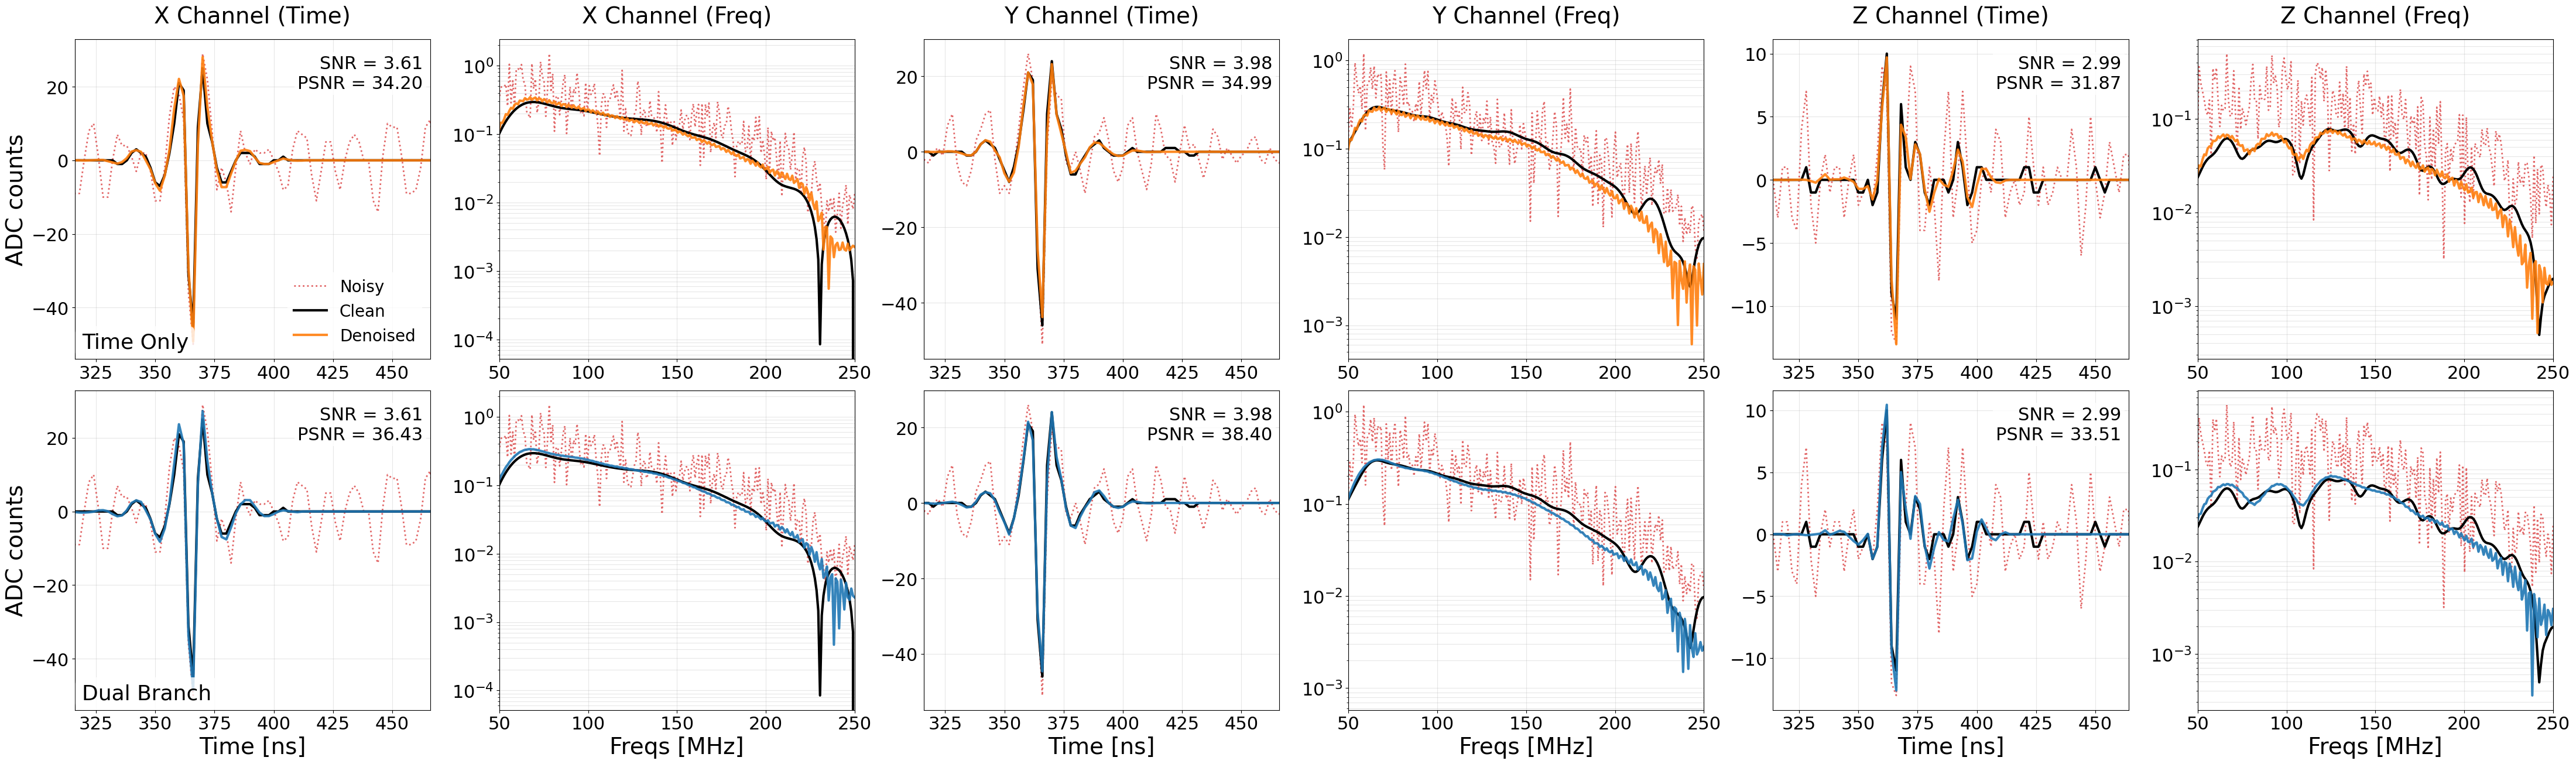

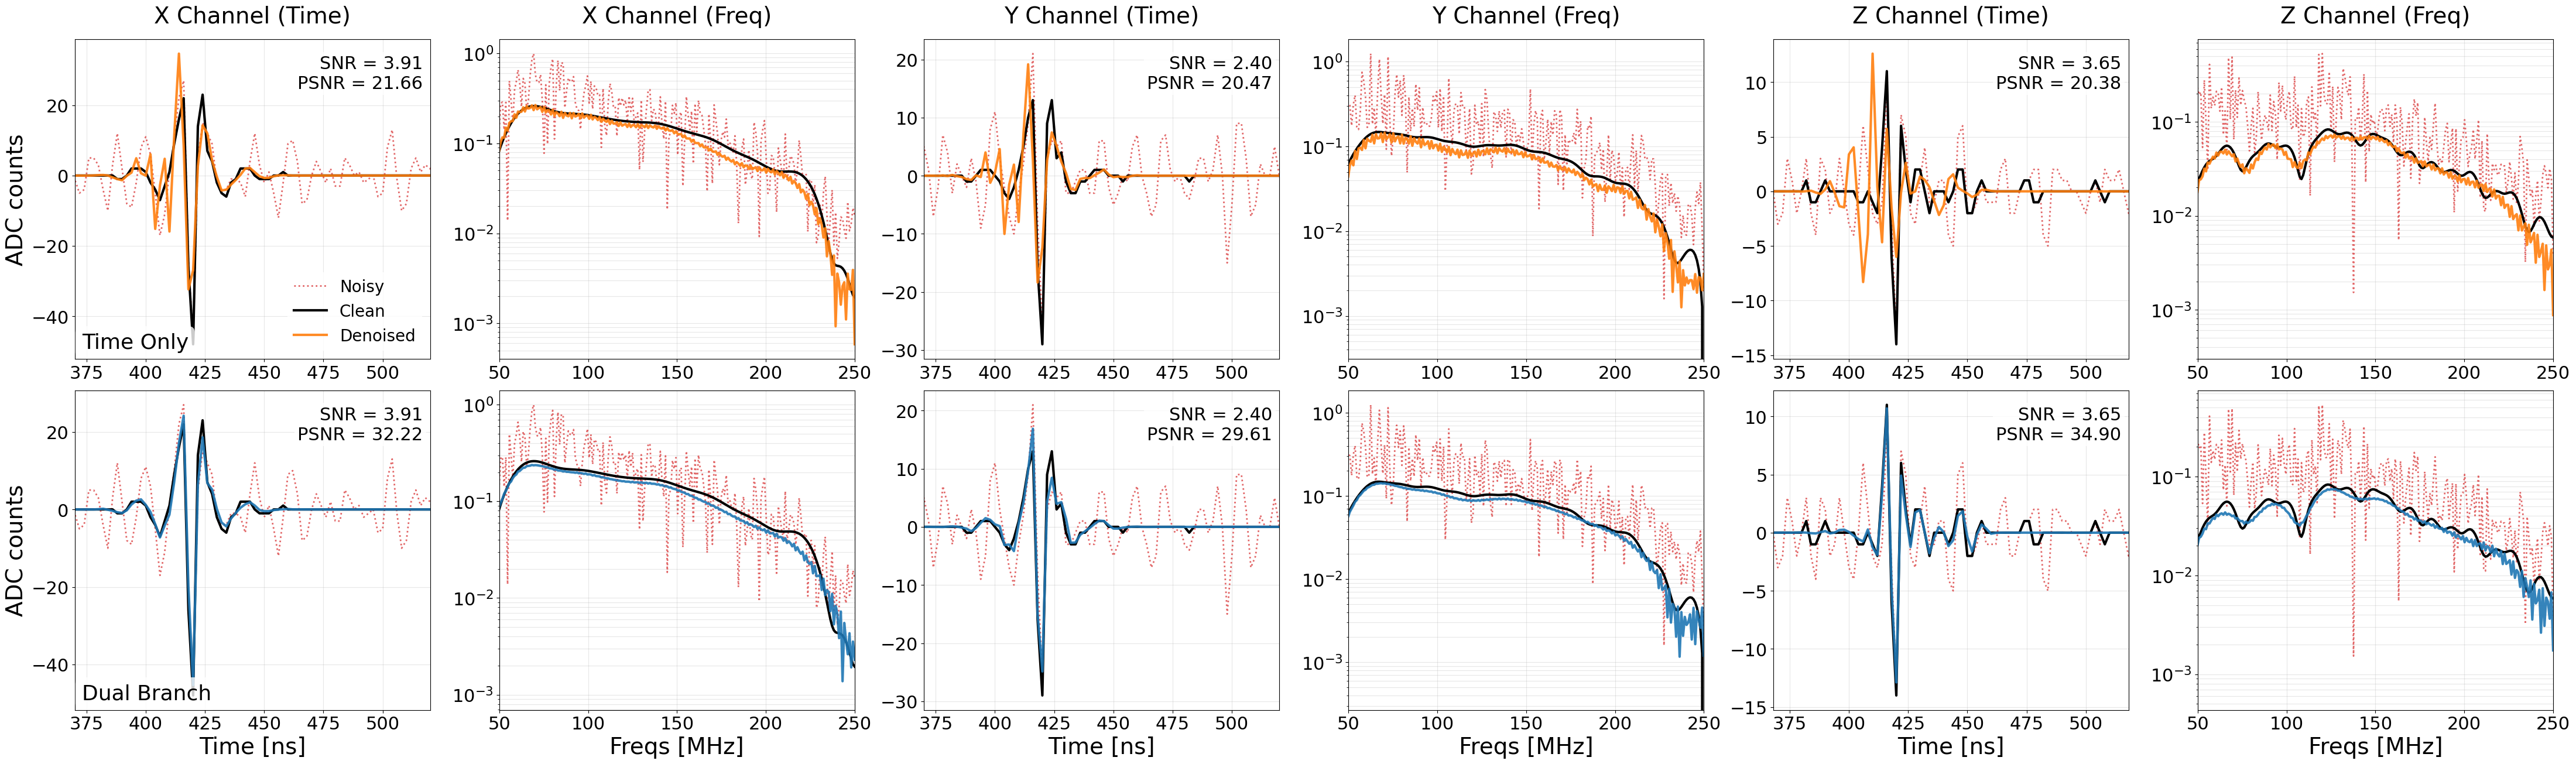

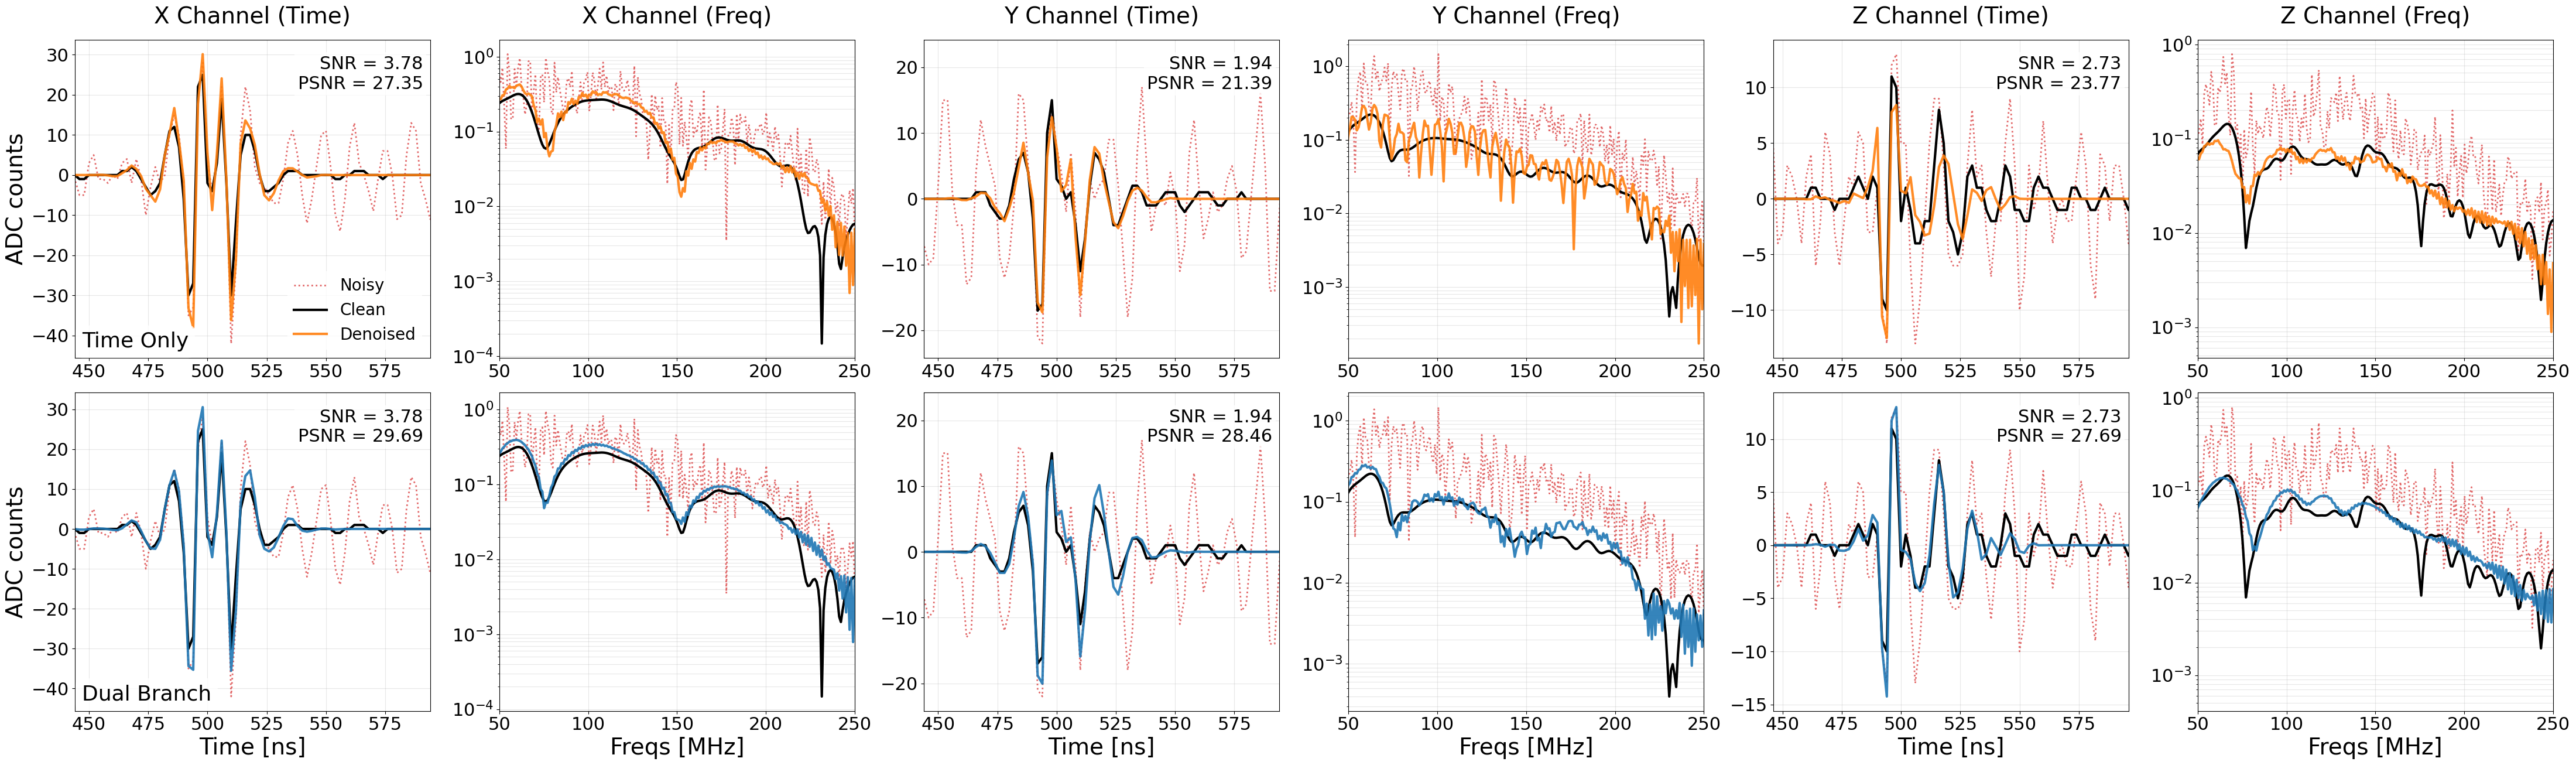

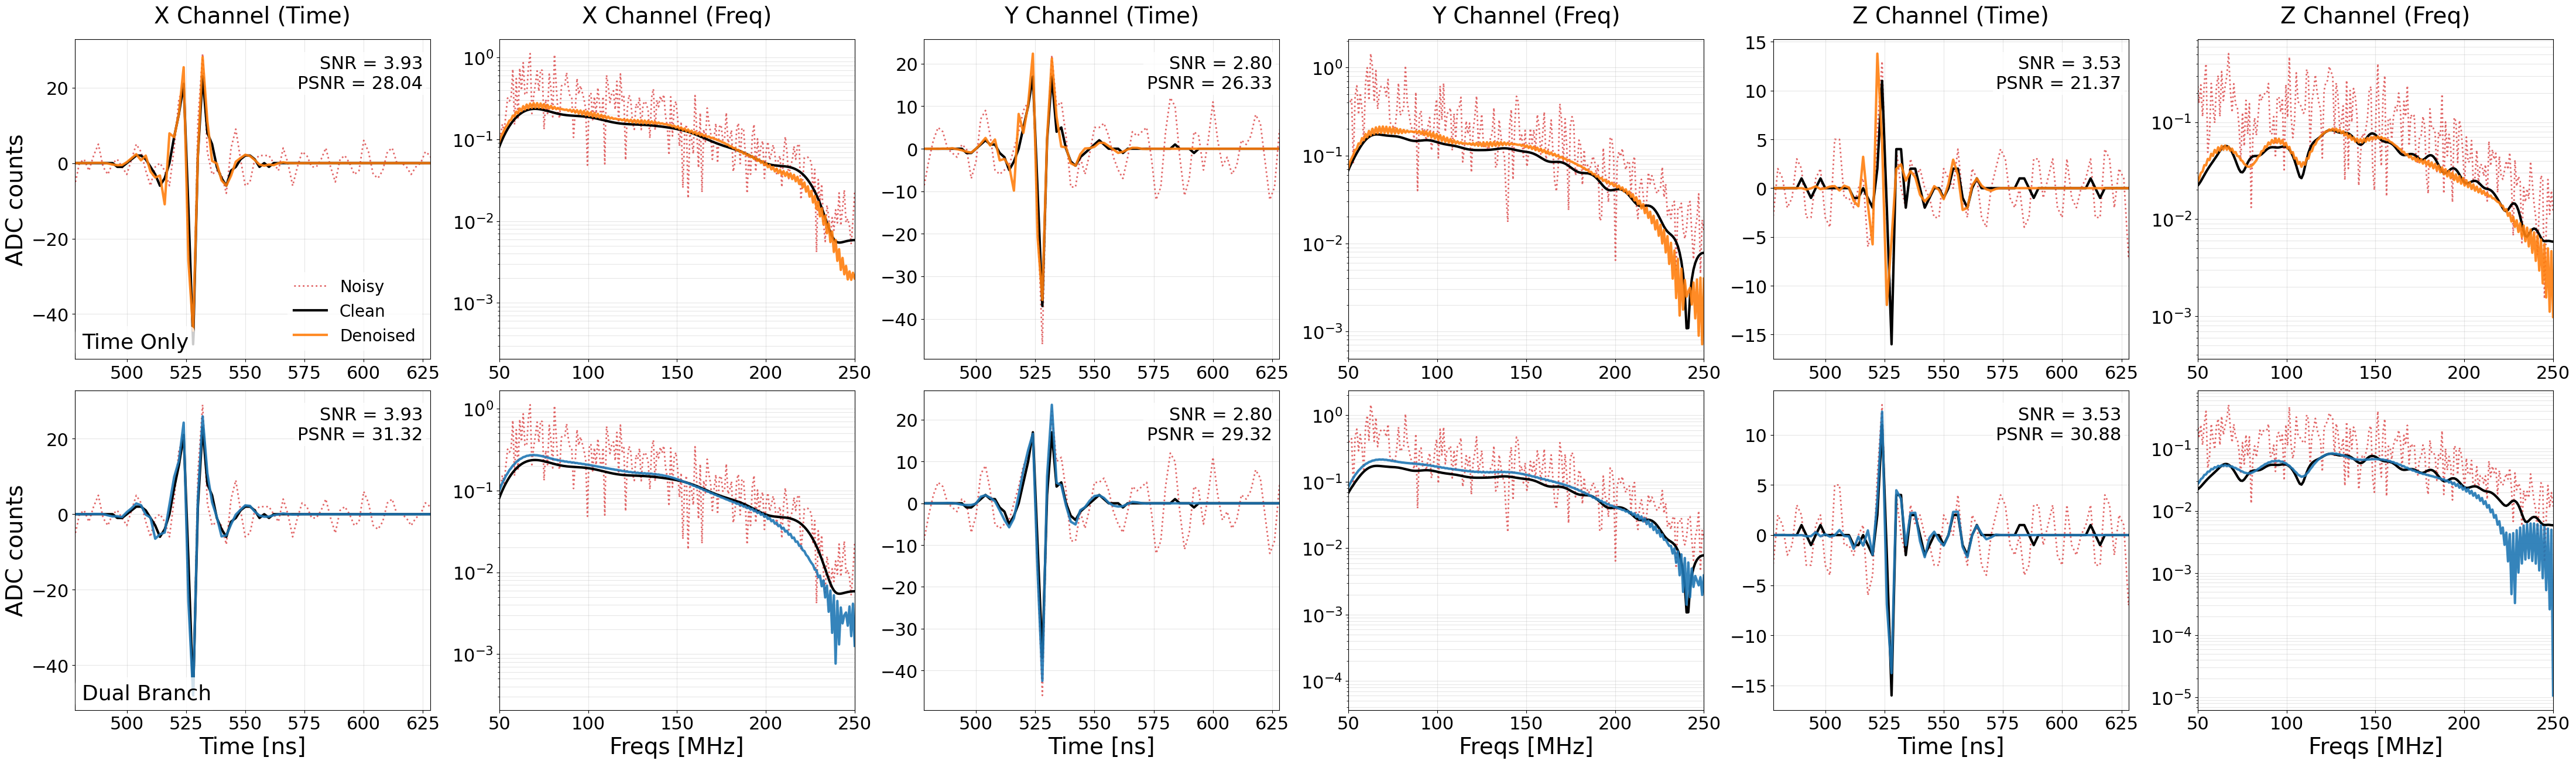

Time & Frequency Traces comparison completed


In [16]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert

# Helper function: Calculate PSNR
def calculate_psnr(true_np, pred_np, peak):
    mse = np.mean((true_np - pred_np)**2)
    return 10 * np.log10((peak**2) / mse) if mse > 0 else 100

def ablation_traces_plot_time_frequency(testloader, 
                                        models,
                                        num_images=6, 
                                        device="cpu", 
                                        save_path='',
                                        snr_min=1,
                                        snr_max=4,
                                        peak_amp_threshold=15,
                                        dt_ns=2.0):  # Added sampling interval, typically 2.0ns
    """
    Plot time-domain + frequency-domain comparison for ablation study.
    Layout: number of models (Rows) x 6 columns (X Time, X Freq, Y Time, Y Freq, Z Time, Z Freq)
    """
    if save_path and not os.path.exists(save_path):
        os.makedirs(save_path, exist_ok=True)
    
    with torch.no_grad():  
        device = torch.device(device)
        for model in models.values():
            model.to(device).eval()
            
        model_names = list(models.keys())
        num_models = len(model_names)
        
        # Assign colors
        color_palette = ['tab:orange', 'tab:blue', 'tab:green', 'tab:red']
        colors = {name: color_palette[i % len(color_palette)] for i, name in enumerate(model_names)}
        
        count = 0
        for noisy_data, clean_data in testloader:
            if count >= num_images: 
                break
            
            noisy_data, clean_data = noisy_data.to(device), clean_data.to(device)
            
            # Get predictions from all models
            model_outputs = {}
            for model_name, model in models.items():
                model_outputs[model_name] = model(noisy_data)
            
            batch_size = noisy_data.size(0)
            signal_length = clean_data.size(-1)
            dt_s = dt_ns * 1e-9  # Convert ns to seconds
            
            for sample_idx in range(batch_size):
                if count >= num_images:
                    break
                
                # Check if all channels meet the SNR and amplitude requirements
                valid_sample = True
                snrs = []
                peak_amps = []
                
                for channel_idx in range(3):
                    clean_np = clean_data[sample_idx, channel_idx].cpu().numpy()
                    noisy_np = noisy_data[sample_idx, channel_idx].cpu().numpy()
                    
                    if np.std(noisy_np) != 0:
                        snr = np.max(clean_np) / np.std(noisy_np)
                    else:
                        snr = float('inf')
                    
                    envelope_clean = np.abs(hilbert(clean_np))
                    peak_amp = np.max(envelope_clean)
                    
                    snrs.append(snr)
                    peak_amps.append(peak_amp)
                    
                    if not (snr_min < snr < snr_max) or peak_amp <= peak_amp_threshold:
                        valid_sample = False
                        break
                
                if not valid_sample:
                    continue
            
                channel_names = ['X Channel', 'Y Channel', 'Z Channel']
                
                # Create grid: num_models x 6
                fig, axes = plt.subplots(num_models, 6, figsize=(45, 7 * num_models))
                if num_models == 1:
                    axes = np.expand_dims(axes, axis=0)
                
                fontsize = 28
                
                for row_idx, model_name in enumerate(model_names):
                    for channel_idx in range(3):
                        # Get numpy arrays
                        clean_np = clean_data[sample_idx, channel_idx].cpu().numpy()
                        noisy_np = noisy_data[sample_idx, channel_idx].cpu().numpy()
                        denoised_np = model_outputs[model_name][sample_idx, channel_idx].cpu().numpy()
                        
                        snr = snrs[channel_idx]
                        psnr_value = calculate_psnr(clean_np, denoised_np, np.max(clean_np))
                        
                        time_bin = np.arange(0, clean_np.size) * dt_ns
                        envelope_true = np.abs(hilbert(clean_np))
                        peak_time_true = time_bin[np.argmax(envelope_true)]
                        
                        # ==========================================
                        # 1. Time Domain Plot -> placed in even columns 0, 2, 4
                        # ==========================================
                        ax_time = axes[row_idx, channel_idx * 2]
                        
                        ax_time.plot(time_bin, noisy_np, label='Noisy', linestyle=':', color='tab:red', linewidth=2, alpha=0.7)
                        ax_time.plot(time_bin, clean_np, label='Clean', color='black', linewidth=3)
                        ax_time.plot(time_bin, denoised_np, label='Denoised', color=colors[model_name], alpha=0.9, linewidth=3)
                        
                        ax_time.set_xlim(peak_time_true - 50, peak_time_true + 100)
                        
                        # Add metrics
                        metrics_text = f"SNR = {snr:.2f}\nPSNR = {psnr_value:.2f}"
                        ax_time.text(0.98, 0.95, metrics_text, 
                               transform=ax_time.transAxes, fontsize=fontsize-6, 
                               verticalalignment='top', horizontalalignment='right',
                               bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
                        
                        if row_idx == 0:
                            ax_time.set_title(f'{channel_names[channel_idx]} (Time)', fontsize=fontsize, pad=20)
                        
                        if channel_idx == 0:
                            ax_time.text(0.02, 0.02, f'{model_name}', 
                                   transform=ax_time.transAxes, fontsize=fontsize-2, 
                                   verticalalignment='bottom', horizontalalignment='left',
                                   bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round'))
                        
                        if row_idx == 0 and channel_idx == 0:
                            legend = ax_time.legend(fontsize=fontsize-8, loc='lower right')
                            legend.get_frame().set_edgecolor('none')
                        
                        if row_idx == num_models - 1:
                            ax_time.set_xlabel('Time [ns]', fontsize=fontsize)
                        
                        if channel_idx == 0:
                            ax_time.set_ylabel('ADC counts', fontsize=fontsize)
                        
                        ax_time.tick_params(axis='both', labelsize=fontsize-6)
                        ax_time.grid(True, alpha=0.3)

                        # ==========================================
                        # 2. Freq Domain Plot -> placed in odd columns 1, 3, 5
                        # ==========================================
                        ax_freq = axes[row_idx, channel_idx * 2 + 1]
                        
                        # Compute FFT
                        freqs_hz = np.fft.rfftfreq(signal_length, d=dt_s)
                        freqs_mhz = freqs_hz / 1e6
                        
                        mag_noisy = np.abs(np.fft.rfft(noisy_np)) / signal_length
                        mag_clean = np.abs(np.fft.rfft(clean_np)) / signal_length
                        mag_denoised = np.abs(np.fft.rfft(denoised_np)) / signal_length
                        
                        ax_freq.semilogy(freqs_mhz, mag_noisy, label='Noisy', linestyle=':', color='tab:red', linewidth=2, alpha=0.7)
                        ax_freq.semilogy(freqs_mhz, mag_clean, label='Clean', color='black', linewidth=3)
                        ax_freq.semilogy(freqs_mhz, mag_denoised, label='Denoised', color=colors[model_name], alpha=0.9, linewidth=3)
                        
                        # Set frequency range (keep consistent with original function)
                        ax_freq.set_xlim(50, 250)
                        
                        if row_idx == 0:
                            ax_freq.set_title(f'{channel_names[channel_idx]} (Freq)', fontsize=fontsize, pad=20)
                        
                        if row_idx == num_models - 1:
                            ax_freq.set_xlabel('Freqs [MHz]', fontsize=fontsize)
                        
                        ax_freq.tick_params(axis='both', labelsize=fontsize-6)
                        ax_freq.grid(True, alpha=0.3, which='both')

                plt.tight_layout(rect=[0.02, 0.02, 1, 0.96])
                
                if save_path:
                    filename = f'ablation_time_freq_snr_{snrs[0]:.2f}_{count:03d}.pdf'
                    plt.savefig(os.path.join(save_path, filename), dpi=200, bbox_inches='tight')
                plt.show()
                count += 1

            if count >= num_images:
                break
    
    print('Time & Frequency Traces comparison completed')

# ==============================================================
# Execution block (Run below in the same cell)
# ==============================================================

models_to_compare = {
    'Time Only': model_time,
    'Dual Branch': model_dual
}

ablation_traces_plot_time_frequency(
    testloader=test_loader, 
    models=models_to_compare,
    num_images=4,             # Number of images to plot
    device='cuda',            # Change to 'cpu' if running on CPU
    snr_min=1,               
    snr_max=4,               
    peak_amp_threshold=15,   
    dt_ns=2.0,                # Must specify your time sampling rate, otherwise frequency x-axis will be wrong
    save_path='/pbs/home/o/omacias/Sam_project/raytune_lib_final/visualization/time_vs_freq_model/best_figures_csv' 
)


Flattening channels and computing SNR...
Computing physics efficiencies...
Plotting comparison...
Figure saved to: figures_csv/physics_efficiency_ablation_comparison.pdf


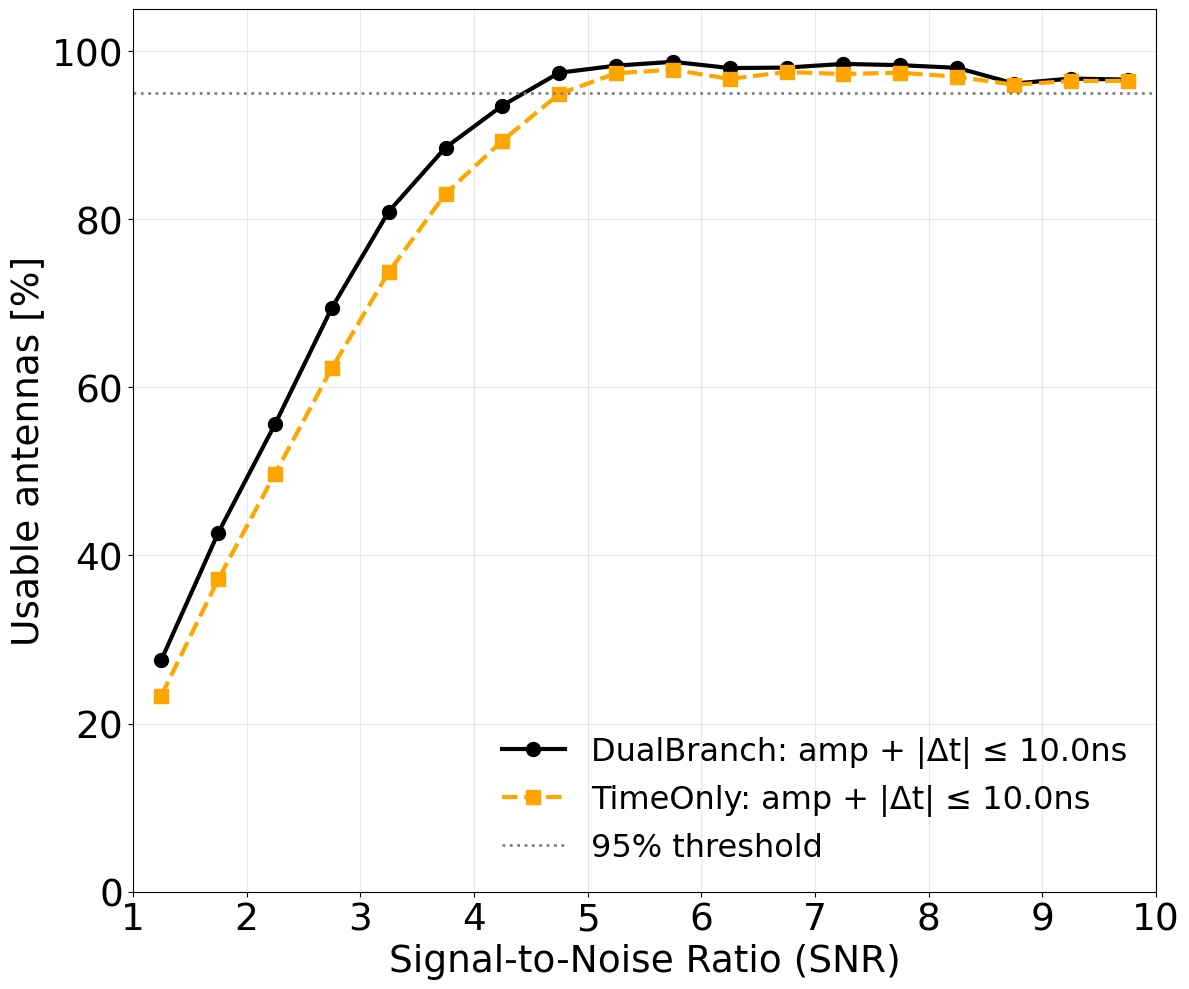

In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt
from evaluation.physics_impact.physics_impact import compute_efficiencies_per_snr

def plot_ablation_usable_antennas(
    clean_all, noisy_all, dual_all, time_all, 
    save_path="figures_csv/physics_efficiency_ablation.pdf"
):
    print("Flattening channels and computing SNR...")
    # Following the standard logic of physics_impact, flatten (N, 3, T) to (N*3, T) to compute per-channel
    clean_flat = clean_all.reshape(-1, clean_all.shape[-1])
    noisy_flat = noisy_all.reshape(-1, noisy_all.shape[-1])
    dual_flat = dual_all.reshape(-1, dual_all.shape[-1])
    time_flat = time_all.reshape(-1, time_all.shape[-1])
    
    # Compute SNR for each trace: max(abs(clean)) / std(noisy)
    snr_values = []
    for c_tr, n_tr in zip(clean_flat, noisy_flat):
        n_std = np.std(n_tr)
        snr_values.append(np.max(np.abs(c_tr)) / n_std if n_std > 0 else float('inf'))
    snr_values = np.array(snr_values)
    
    # Core threshold parameters for physics evaluation (aligned with original settings)
    snr_min, snr_max, snr_step = 1.0, 10.0, 0.5
    amp_threshold = 2.0
    t_max_ns = 10.0
    dt_ns = 2.0  # Note: ADC sampling interval is typically 2.0ns
    
    snr_bins = np.arange(snr_min, snr_max + snr_step, snr_step)
    
    print("Computing physics efficiencies...")
    # Core invocation: directly use physics_impact's underlying function for rigorous evaluation
    centers, eps_dual, _ = compute_efficiencies_per_snr(
        snr_values, clean_flat, dual_flat, snr_bins, amp_threshold, t_max_ns, dt_ns
    )
    _, eps_time, _ = compute_efficiencies_per_snr(
        snr_values, clean_flat, time_flat, snr_bins, amp_threshold, t_max_ns, dt_ns
    )
    
    print("Plotting comparison...")
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # DualBranch as black solid line
    ax.plot(centers, eps_dual * 100, marker="o", linestyle="-", color="black", 
            linewidth=3, markersize=10, label=f"DualBranch: amp + |Δt| ≤ {t_max_ns}ns")
            
    # TimeOnly as orange dashed line
    ax.plot(centers, eps_time * 100, marker="s", linestyle="--", color="orange", 
            linewidth=3, markersize=10, label=f"TimeOnly: amp + |Δt| ≤ {t_max_ns}ns")
    
    ax.axhline(95.0, linestyle=":", linewidth=2.0, color="gray", label="95% threshold")
    
    fontsize = 27
    ax.set_xlabel("Signal-to-Noise Ratio (SNR)", fontsize=fontsize)
    ax.set_ylabel("Usable antennas [%]", fontsize=fontsize)
    ax.tick_params(axis='both', which='major', labelsize=fontsize)
    ax.set_ylim(0.0, 105.0)
    ax.set_xlim(snr_min, snr_max)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(loc="lower right", fontsize=fontsize - 4, frameon=False)
    
    plt.tight_layout()
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, bbox_inches='tight')
    print(f"Figure saved to: {save_path}")
    plt.show()

# ==============================================================
# Execution block: Directly pass the previously extracted NumPy arrays
# ==============================================================
plot_ablation_usable_antennas(
    clean_all=clean_all, 
    noisy_all=noisy_all, 
    dual_all=dual_all, 
    time_all=time_all,
    save_path='figures_csv/physics_efficiency_ablation_comparison.pdf'
)
